In [1]:
import pandas as pd

In [2]:


data = pd.read_csv('data/RNA-Seq-expression-Norilsk2019.csv')

In [3]:
data

,Gene,Species,log_2 fold change,Adjusted p-value
0,ENSG00000181577,homo sapiens,-6.8,6.395631e-214
1,ENSG00000128322,homo sapiens,-6.0,5.979922e-32
2,ENSG00000177606,homo sapiens,5.8,0.000000e+00
3,ENSG00000148600,homo sapiens,-5.8,7.926548e-166
4,ENSG00000164309,homo sapiens,5.6,1.625288e-84
...,...,...,...,...
995,ENSG00000137221,homo sapiens,1.7,5.994751e-72
996,ENSG00000092020,homo sapiens,1.7,3.487785e-71
997,ENSG00000089195,homo sapiens,1.7,8.793077e-71
998,ENSG00000179832,homo sapiens,-1.7,9.521317e-71


In [9]:
data

,Gene,Species,log_2 fold change,Adjusted p-value,significance,neg_log10_pval
0,ENSG00000181577,homo sapiens,-6.8,6.395631e-214,Subexpresado,213.194117
1,ENSG00000128322,homo sapiens,-6.0,5.979922e-32,Subexpresado,31.223304
2,ENSG00000177606,homo sapiens,5.8,0.000000e+00,Sobreexpresado,300.000000
3,ENSG00000148600,homo sapiens,-5.8,7.926548e-166,Subexpresado,165.100916
4,ENSG00000164309,homo sapiens,5.6,1.625288e-84,Sobreexpresado,83.789070
...,...,...,...,...,...,...
995,ENSG00000137221,homo sapiens,1.7,5.994751e-72,Sobreexpresado,71.222229
996,ENSG00000092020,homo sapiens,1.7,3.487785e-71,Sobreexpresado,70.457450
997,ENSG00000089195,homo sapiens,1.7,8.793077e-71,Sobreexpresado,70.055859
998,ENSG00000179832,homo sapiens,-1.7,9.521317e-71,Subexpresado,70.021303


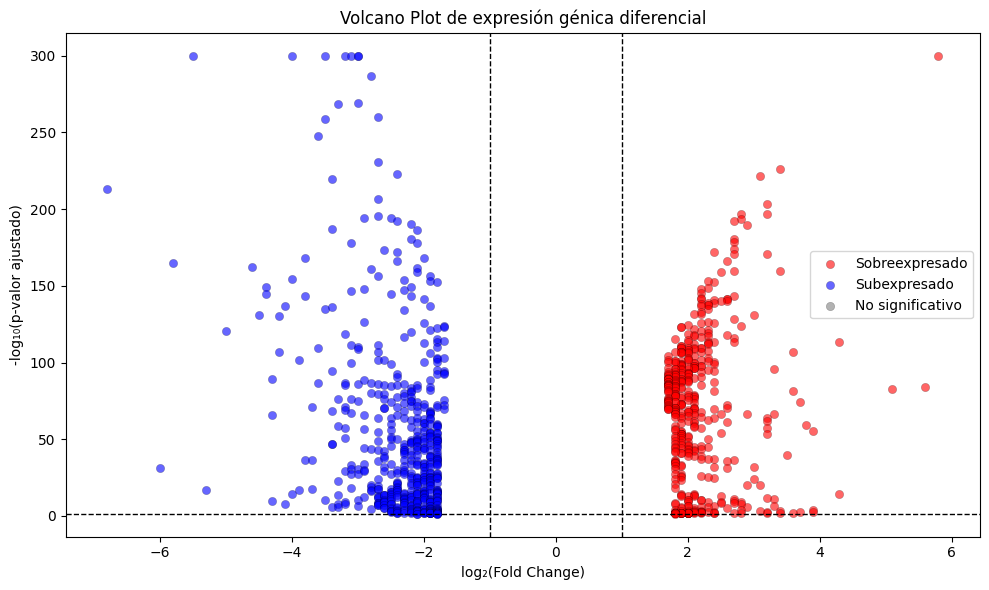

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Cargar los datos (ajusta según tu fuente)
# data = pd.read_csv('ruta/del/archivo.csv')  # si es externo
# o ya lo tienes en memoria como 'data'

# Parámetros de corte
log2fc_threshold = 1
pval_threshold = 0.05

# Clasificación
data['significance'] = 'No significativo'
data.loc[(data['log_2 fold change'] >= log2fc_threshold) & (data['Adjusted p-value'] < pval_threshold), 'significance'] = 'Sobreexpresado'
data.loc[(data['log_2 fold change'] <= -log2fc_threshold) & (data['Adjusted p-value'] < pval_threshold), 'significance'] = 'Subexpresado'

# -log10(p-valor) para el eje y
data['neg_log10_pval'] = -np.log10(data['Adjusted p-value'].replace(0, 1e-300))  # Evita log(0)

# Colores
colors = {
    'Sobreexpresado': 'red',
    'Subexpresado': 'blue',
    'No significativo': 'gray'
}

# Volcano plot
plt.figure(figsize=(10, 6))
for category, color in colors.items():
    subset = data[data['significance'] == category]
    plt.scatter(subset['log_2 fold change'], subset['neg_log10_pval'], 
                c=color, label=category, alpha=0.6, edgecolors='k', linewidths=0.2)

# Líneas de corte
plt.axhline(-np.log10(pval_threshold), color='black', linestyle='--', lw=1)
plt.axvline(log2fc_threshold, color='black', linestyle='--', lw=1)
plt.axvline(-log2fc_threshold, color='black', linestyle='--', lw=1)

plt.title('Volcano Plot de expresión génica diferencial')
plt.xlabel('log₂(Fold Change)')
plt.ylabel('-log₁₀(p-valor ajustado)')
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
print(results.columns.tolist())
print(results.head())


['source', 'native', 'name', 'p_value', 'significant', 'description', 'term_size', 'query_size', 'intersection_size', 'effective_domain_size', 'precision', 'recall', 'query', 'parents']
  source      native                               name       p_value  \
0  GO:CC  GO:0005737                          cytoplasm  1.550764e-23   
1  GO:MF  GO:0005515                    protein binding  3.379725e-17   
2  GO:CC  GO:0005654                        nucleoplasm  2.319861e-15   
3     TF   TF:M00333  Factor: ZF5; motif: NRNGNGCGCGCWN  9.124300e-15   
4  GO:CC  GO:0043226                          organelle  5.659639e-14   

   significant                                        description  term_size  \
0         True  "The contents of a cell excluding the plasma m...      12394   
1         True          "Binding to a protein." [GOC:go_curators]      14865   
2         True  "That part of the nuclear content other than t...       4229   
3         True                  Factor: ZF5; motif: NRN

In [7]:
from gprofiler import GProfiler
import pandas as pd

# Extraer genes diferencialmente expresados
log2fc_threshold = 1
pval_threshold = 0.05

genes_sig = data[
    (data['Adjusted p-value'] < pval_threshold) & (abs(data['log_2 fold change']) > log2fc_threshold)
]['Gene'].tolist()

# Inicializar g:Profiler
gp = GProfiler(return_dataframe=True)

# Análisis de enriquecimiento (organismo humano: 'hsapiens')
results = gp.profile(organism='hsapiens', query=genes_sig)

# Guardar resultados
results.to_csv("enrichment_results_gprofiler.csv", index=False)

# Mostrar top 10 resultados
print(results[['source', 'name', 'p_value']].sort_values('p_value').head(10))


  source                                          name       p_value
0  GO:CC                                     cytoplasm  1.550764e-23
1  GO:MF                               protein binding  3.379725e-17
2  GO:CC                                   nucleoplasm  2.319861e-15
3     TF             Factor: ZF5; motif: NRNGNGCGCGCWN  9.124300e-15
4  GO:CC                                     organelle  5.659639e-14
5  GO:CC            intracellular anatomical structure  2.273045e-13
6  GO:CC      intracellular membrane-bounded organelle  2.340756e-13
7  GO:CC                    membrane-bounded organelle  4.991381e-13
8  GO:CC                       intracellular organelle  1.510599e-12
9     TF  Factor: ZF5; motif: GSGCGCGR; match class: 1  8.994558e-12


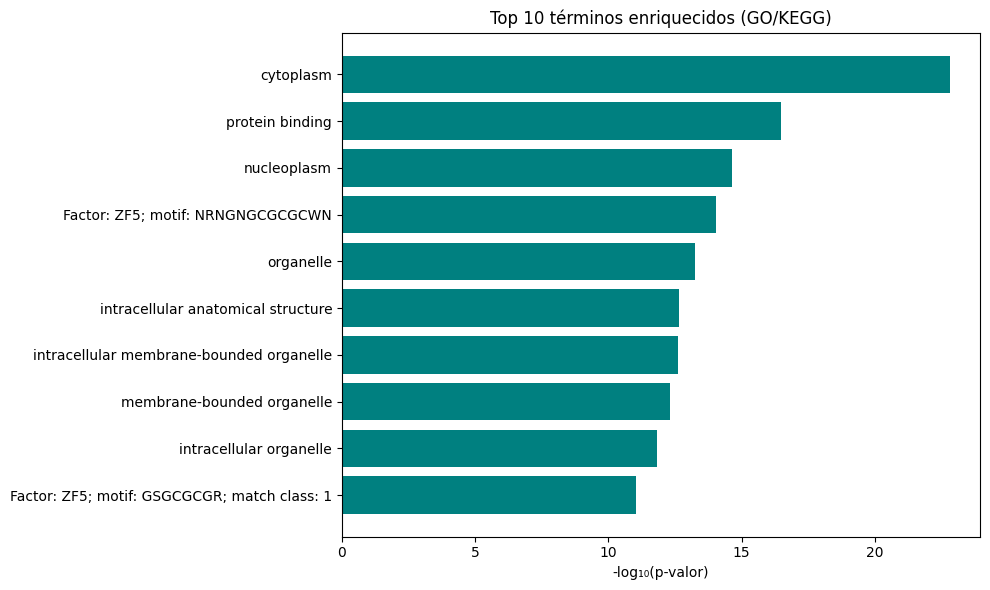

In [8]:
import matplotlib.pyplot as plt

# Tomar los 10 términos más significativos
top_terms = results.sort_values('p_value').head(10)

# Gráfico
plt.figure(figsize=(10, 6))
plt.barh(top_terms['name'], -np.log10(top_terms['p_value']), color='teal')
plt.xlabel('-log₁₀(p-valor)')
plt.title('Top 10 términos enriquecidos (GO/KEGG)')
plt.gca().invert_yaxis()  # Para que el más significativo quede arriba
plt.tight_layout()
plt.show()


In [10]:
genes_sobreexpresados = data[(data['log_2 fold change'] > 1) & (data['Adjusted p-value'] < 0.05)]


In [13]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)

genes_list = genes_sobreexpresados['Gene'].tolist()

# Convertir IDs (ejemplo de Ensembl a Entrez)
conversion = gp.convert(
    query=genes_list,
    target_namespace='ENTREZGENE',
    organism='hsapiens'
)

print(conversion.head())


          incoming converted  n_incoming  n_converted   name  \
0  ENSG00000177606       JUN           1            1    JUN   
1  ENSG00000164309     CMYA5           2            1  CMYA5   
2  ENSG00000184545     DUSP8           3            1  DUSP8   
3  ENSG00000085465     OVGP1           4            1  OVGP1   
4  ENSG00000087589     CASS4           5            1  CASS4   

                                         description         namespaces  \
0  Jun proto-oncogene, AP-1 transcription factor ...  ARRAYEXPRESS,ENSG   
1  cardiomyopathy associated 5 [Source:HGNC Symbo...  ARRAYEXPRESS,ENSG   
2  dual specificity phosphatase 8 [Source:HGNC Sy...  ARRAYEXPRESS,ENSG   
3  oviductal glycoprotein 1 [Source:HGNC Symbol;A...  ARRAYEXPRESS,ENSG   
4  Cas scaffold protein family member 4 [Source:H...  ARRAYEXPRESS,ENSG   

     query  
0  query_1  
1  query_1  
2  query_1  
3  query_1  
4  query_1  


In [17]:
# Extraemos la lista de símbolos de genes convertidos
genes_simbolos = conversion['converted'].dropna().unique().tolist()

# Hacemos el análisis de enriquecimiento GO
go_enrichment = gp.profile(
    organism='hsapiens',
    query=genes_simbolos,
    sources=['GO:BP', 'GO:MF', 'GO:CC']  # Procesos biológicos, funciones moleculares y componentes celulares
)

# Mostrar los primeros 10 términos GO enriquecidos
print(go_enrichment[['name', 'source', 'p_value', 'intersection_size']].head(10))


                                       name source       p_value  \
0                               nucleoplasm  GO:CC  3.108106e-36   
1                             nuclear lumen  GO:CC  1.144660e-25   
2                           organelle lumen  GO:CC  7.587324e-21   
3             intracellular organelle lumen  GO:CC  7.587324e-21   
4                   membrane-enclosed lumen  GO:CC  7.587324e-21   
5                                   nucleus  GO:CC  7.852320e-19   
6  intracellular membrane-bounded organelle  GO:CC  1.012731e-16   
7   regulation of primary metabolic process  GO:BP  6.871750e-16   
8                           protein binding  GO:MF  8.215751e-16   
9                   intracellular organelle  GO:CC  5.804894e-15   

   intersection_size  
0                191  
1                202  
2                216  
3                216  
4                216  
5                276  
6                344  
7                185  
8                362  
9                360 

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


C:\Users\felip\AppData\Local\Temp\ipykernel_12432\825702181.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='-log10(p_value)', y='name', data=top10, palette='viridis')


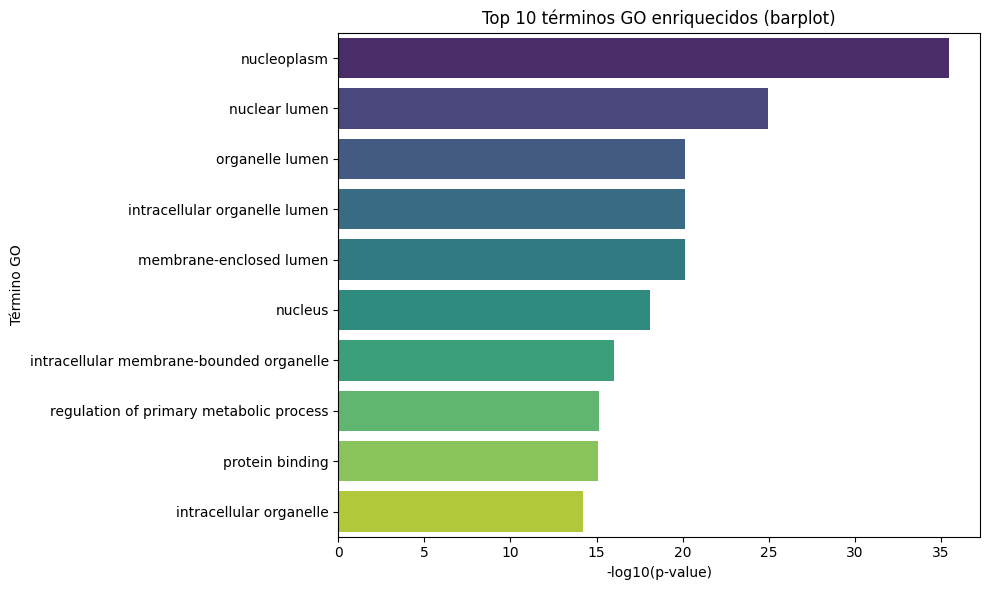

In [19]:
# Ordenar por p-value y seleccionar top 10
top10 = go_enrichment.sort_values('p_value').head(10)

# Para barra invertida y mejor visualización usamos -log10(p_value)
top10['-log10(p_value)'] = -np.log10(top10['p_value'])

plt.figure(figsize=(10,6))
sns.barplot(x='-log10(p_value)', y='name', data=top10, palette='viridis')
plt.xlabel('-log10(p-value)')
plt.ylabel('Término GO')
plt.title('Top 10 términos GO enriquecidos (barplot)')
plt.tight_layout()
plt.show()


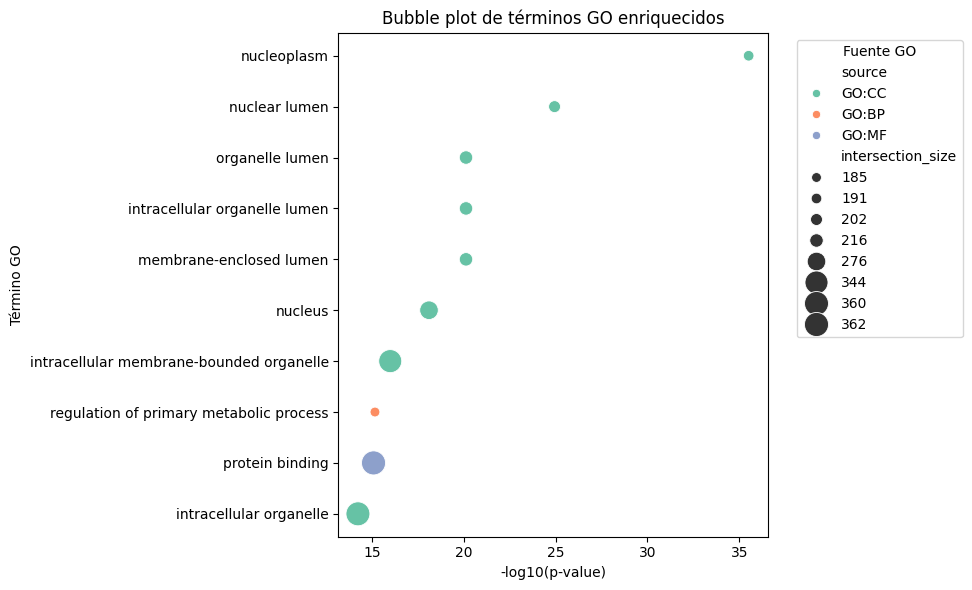

In [21]:
plt.figure(figsize=(10,6))

# Bubble plot: eje X = -log10(p-value), eje Y = nombre, tamaño burbuja = intersection_size
sns.scatterplot(
    x=-np.log10(top10['p_value']),
    y=top10['name'],
    size=top10['intersection_size'],
    hue=top10['source'],
    palette='Set2',
    sizes=(50, 300),
    legend='full'
)

plt.xlabel('-log10(p-value)')
plt.ylabel('Término GO')
plt.title('Bubble plot de términos GO enriquecidos')
plt.legend(title='Fuente GO', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [31]:
data

,Gene,Species,log_2 fold change,Adjusted p-value,significance,neg_log10_pval
0,ENSG00000181577,homo sapiens,-6.8,6.395631e-214,Subexpresado,213.194117
1,ENSG00000128322,homo sapiens,-6.0,5.979922e-32,Subexpresado,31.223304
2,ENSG00000177606,homo sapiens,5.8,0.000000e+00,Sobreexpresado,300.000000
3,ENSG00000148600,homo sapiens,-5.8,7.926548e-166,Subexpresado,165.100916
4,ENSG00000164309,homo sapiens,5.6,1.625288e-84,Sobreexpresado,83.789070
...,...,...,...,...,...,...
995,ENSG00000137221,homo sapiens,1.7,5.994751e-72,Sobreexpresado,71.222229
996,ENSG00000092020,homo sapiens,1.7,3.487785e-71,Sobreexpresado,70.457450
997,ENSG00000089195,homo sapiens,1.7,8.793077e-71,Sobreexpresado,70.055859
998,ENSG00000179832,homo sapiens,-1.7,9.521317e-71,Subexpresado,70.021303


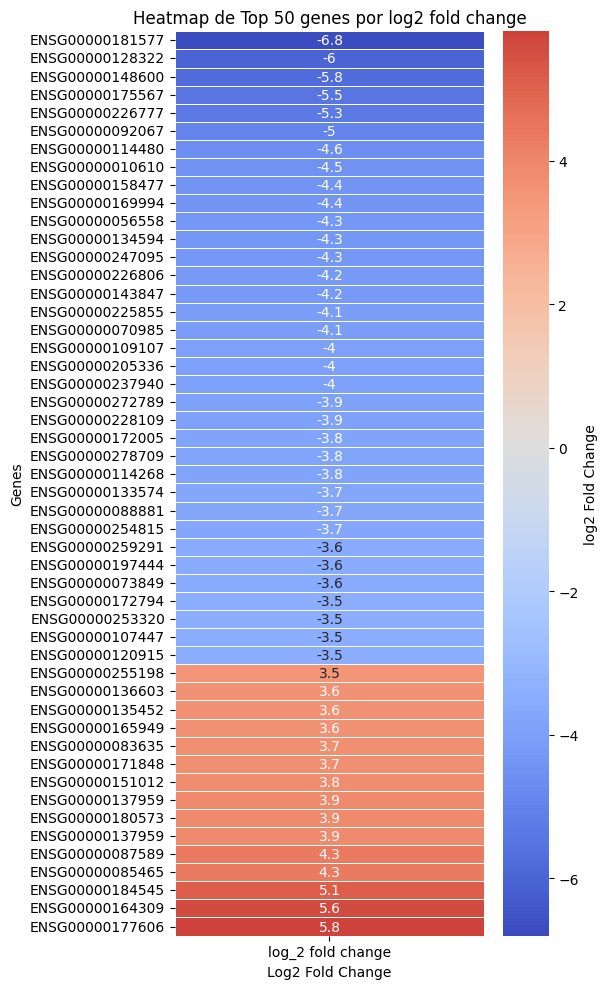

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Supón que 'data' es tu DataFrame cargado

# Filtramos top 50 genes por valor absoluto de log2 fold change
top_genes = data.loc[data['significance'] == 'Sobreexpresado'].nlargest(50, 'log_2 fold change')

# O top 50 en valor absoluto (sobre o sub expresados)
top_genes = data.iloc[(data['log_2 fold change'].abs()).argsort()[-50:]]

# Reordenar por fold change
top_genes = top_genes.sort_values('log_2 fold change')

# Creamos un DataFrame para heatmap con un valor por gen (reshape)
heatmap_data = top_genes.set_index('Gene')[['log_2 fold change']]

plt.figure(figsize=(6,10))
sns.heatmap(
    heatmap_data,
    cmap='coolwarm',
    center=0,
    annot=True,
    linewidths=0.5,
    cbar_kws={'label': 'log2 Fold Change'}
)
plt.title('Heatmap de Top 50 genes por log2 fold change')
plt.ylabel('Genes')
plt.xlabel('Log2 Fold Change')
plt.tight_layout()
plt.show()


In [6]:
#!pip install mygene
import mygene
mg = mygene.MyGeneInfo()

# Lista de genes
genes = ['ENSG00000177606', 'ENSG00000128322']

# Consultar GO terms
results = mg.querymany(genes, scopes='ensembl.gene', fields='go', species='human')

for gene in results:
    print(f"\n{gene.get('query')}")
    go = gene.get('go', {})
    for cat in ['BP', 'MF', 'CC']:
        terms = go.get(cat, [])
        if isinstance(terms, dict):
            terms = [terms]
        for term in terms:
            print(f"  {cat}: {term.get('term')} (GO:{term.get('id')})")


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed



ENSG00000177606
  BP: negative regulation of transcription by RNA polymerase II (GO:GO:0000122)
  BP: negative regulation of transcription by RNA polymerase II (GO:GO:0000122)
  BP: angiogenesis (GO:GO:0001525)
  BP: microglial cell activation (GO:GO:0001774)
  BP: liver development (GO:GO:0001889)
  BP: positive regulation of endothelial cell proliferation (GO:GO:0001938)
  BP: outflow tract morphogenesis (GO:GO:0003151)
  BP: regulation of DNA-templated transcription (GO:GO:0006355)
  BP: regulation of DNA-templated transcription (GO:GO:0006355)
  BP: regulation of transcription by RNA polymerase II (GO:GO:0006357)
  BP: regulation of transcription by RNA polymerase II (GO:GO:0006357)
  BP: apoptotic process (GO:GO:0006915)
  BP: transforming growth factor beta receptor signaling pathway (GO:GO:0007179)
  BP: JNK cascade (GO:GO:0007254)
  BP: JNK cascade (GO:GO:0007254)
  BP: cell population proliferation (GO:GO:0008283)
  BP: negative regulation of cell population proliferation (GO